## Generative Adversarial Network (GAN)


GANs are models that generate new, realistic data by learning from existing data. Introduced by Ian Goodfellow in 2014, they enable machines to create content like images, videos and music.

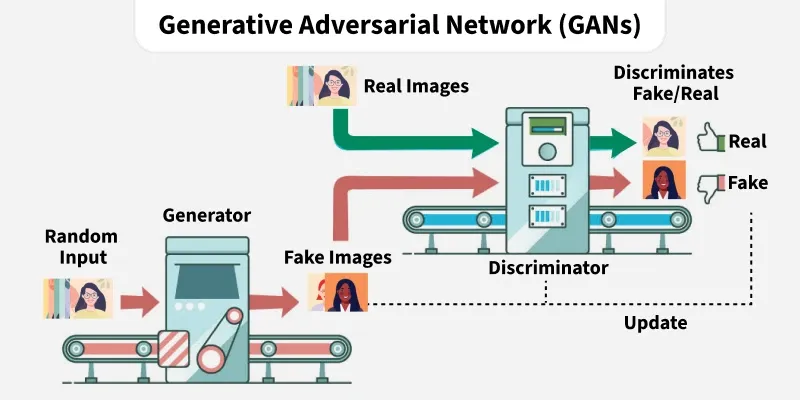

## Architecture of GAN

GAN consists of two neural networks the generator and the discriminator trained adversarially, where the generator tries to fool the discriminator and the discriminator tries to distinguish real from fake data.

### 1. Generator Model
The generator is a deep neural network that takes random noise as input to generate realistic data samples like images or text. It learns the underlying data patterns by adjusting its internal parameters during training through backpropagation. Its objective is to produce samples that the discriminator classifies as real.

Generator Loss Function: The generator tries to minimize this loss:
$$L_G = -\log(D(G(z)))$$

Where:
- $G(z)$ is the output of the generator given random noise $z$.
- $D(G(z))$ is the discriminator's output for the generated data.   

### 2. Discriminator Model
The discriminator is a binary classifier that distinguishes real data from generated samples. Through training, it refines its parameters to improve detection of fake data and when working with images, it uses convolutional layers to extract features and enhance classification accuracy.

Discriminator Loss Function: The discriminator tries to minimize this loss:
$$L_D = -\log(D(x)) - \log(1 - D(G(z)))$$

Where:
- $x$ is a real data sample.
- $G(z)$ is the output of the generator given random noise $z$.
- $D(x)$ is the discriminator's output for the real data.
- $D(G(z))$ is the discriminator's output for the generated data.

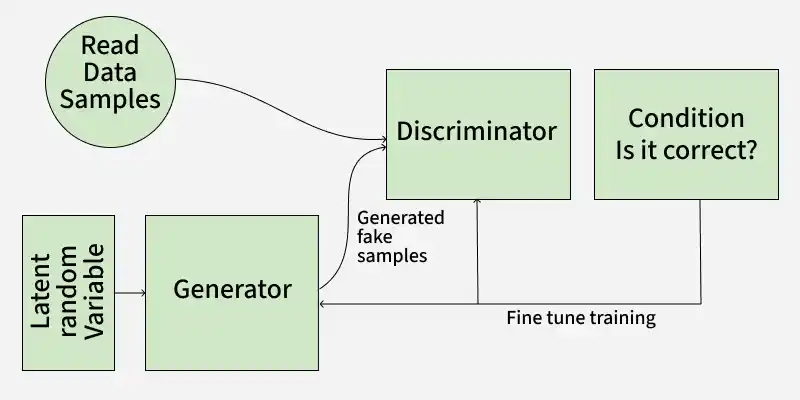

GANs are trained using a MinMax Loss between the generator and discriminator:
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$

Where:
- $p_{data}(x)$ is the distribution of real data.
- $p_z(z)$ is the distribution of random noise. 

### Working of GAN

1. **Initialization**: Both the generator and discriminator are initialized with random weights.
2. **Training Loop**:
   - **Discriminator Training**: The discriminator is trained on a batch of real data and a batch of generated data. It updates its weights to better distinguish between the two.
   - **Generator Training**: The generator is trained to produce data that can fool the discriminator. It updates its weights based on the feedback from the discriminator.
3. **Convergence**: The training continues until the generator produces data that the discriminator cannot reliably distinguish from real data, indicating that the generator has learned to create realistic samples.

### Types of GAN

1. **DCGAN (Deep Convolutional GAN)**: Uses convolutional layers in both the generator and discriminator, making it effective for image generation tasks.

2. **WGAN (Wasserstein GAN)**: Introduces a new loss function based on the Wasserstein distance, improving training stability and addressing issues like mode collapse.

3. **CycleGAN**: Enables image-to-image translation without paired data, allowing for tasks like style transfer and domain adaptation.

4. **StyleGAN**: Focuses on generating high-quality images with control over style and features, often used for creating realistic human faces.

5. **Conditional GAN (cGAN)**: Allows for generating data conditioned on specific labels or attributes, enabling more controlled generation.

6. **Pix2Pix**: A type of cGAN designed for paired image-to-image translation tasks, such as converting sketches to photos.

7. **Vanilla GAN**: The original GAN architecture proposed by Ian Goodfellow, which serves as the foundation for many subsequent GAN variants.

## Implementation



### Step 1: Importing Required Libraries
We will be using Pytorch, Torchvision, Matplotlib and Numpy libraries for this. Set the device to GPU if available otherwise use CPU.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Step 2: Defining Image Transformations
We use PyTorch’s transforms to convert images to tensors and normalize pixel values between -1 and 1 for better training stability.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

### Step 3: Loading the CIFAR-10 Dataset

In [ ]:
train_dataset = datasets.CIFAR10(root='./data',\
              train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(train_dataset, \
                                batch_size=32, shuffle=True)

### Step 4: Defining GAN Hyperparameters
Set important training parameters:

* latent_dim: Dimensionality of the noise vector.
* lr: Learning rate of the optimizer.
* beta1, beta2: Beta parameters for Adam optimizer (e.g 0.5, 0.999)
* num_epochs: Number of times the entire dataset will be processed (e.g 10)

In [ ]:
latent_dim = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
num_epochs = 10

### Step 5: Building the Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.78),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img

### Step 6: Building the Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.ZeroPad2d((0, 1, 0, 1)),
        nn.BatchNorm2d(64, momentum=0.82),
        nn.LeakyReLU(0.25),
        nn.Dropout(0.25),
        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(128, momentum=0.82),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256, momentum=0.8),
        nn.LeakyReLU(0.25),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(256 * 5 * 5, 1),
        nn.Sigmoid()
    )

    def forward(self, img):
        validity = self.model(img)
        return validity

### Step 7: Initializing GAN Components

In [ ]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters()\
                         , lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters()\
                         , lr=lr, betas=(beta1, beta2))

### Step 8: Training the GAN

In [ ]:
for epoch in range(num_epochs):
    for i, batch in enumerate(dataloader):
       
        real_images = batch[0].to(device) 
       
        valid = torch.ones(real_images.size(0), 1, device=device)
        fake = torch.zeros(real_images.size(0), 1, device=device)
       
        real_images = real_images.to(device)

        optimizer_D.zero_grad()
       
        z = torch.randn(real_images.size(0), latent_dim, device=device)
      
        fake_images = generator(z)

        real_loss = adversarial_loss(discriminator\
                                     (real_images), valid)
        fake_loss = adversarial_loss(discriminator\
                                     (fake_images.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
    
        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
      
        gen_images = generator(z)
        
        g_loss = adversarial_loss(discriminator(gen_images), valid)
        g_loss.backward()
        optimizer_G.step()
       
        if (i + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}]\
                        Batch {i+1}/{len(dataloader)} "
                f"Discriminator Loss: {d_loss.item():.4f} "
                f"Generator Loss: {g_loss.item():.4f}"
            )
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(16, latent_dim, device=device)
            generated = generator(z).detach().cpu()
            grid = torchvision.utils.make_grid(generated,\
                                        nrow=4, normalize=True)
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.axis("off")
            plt.show()

                                                             Image Generation using Generative Adversarial Networks (GANs) using TensorFlow                                 


## Image Generation using Generative Adversarial Networks (GANs) using TensorFlow


Generative Adversarial Networks (GANs) revolutionized AI image generation by creating realistic and high-quality images from random noise. In this article, we will train a GAN model on the MNIST dataset to generate handwritten digit images.

### Step 1: Import Necessary Libraries and Load Dataset

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

### Step 2: Dataset Preparation

In [6]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

### Step 3: Building the Models

In [10]:
def build_discriminator_cnn():
    model = models.Sequential([
        
        layers.Conv2D(64, kernel_size=3, strides=2, input_shape=(28, 28, 1), padding='same', activation='relu'),
        
        layers.Conv2D(128, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.BatchNormalization(),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

def build_generator_cnn():
    model = models.Sequential([
        layers.Dense(7 * 7 * 128, input_dim=100, activation='relu'),
        layers.Reshape((7, 7, 128)),
        layers.UpSampling2D(),
        layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.UpSampling2D(),
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(1, kernel_size=3, padding='same', activation='sigmoid')
    ])
    return model

### Step 4: Compiling the Models

In [11]:
generator_cnn = build_generator_cnn()
discriminator_cnn = build_discriminator_cnn()

discriminator_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
                          loss='binary_crossentropy', 
                          metrics=['accuracy'])

discriminator_cnn.trainable = False

gan_input = layers.Input(shape=(100,))
gan_output = discriminator_cnn(generator_cnn(gan_input))
gan_cnn = models.Model(gan_input, gan_output)
gan_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
                loss='binary_crossentropy')

c:\Users\PANDIT JI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\PANDIT JI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 5: Model Training and Visualizing

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Epoch 0: D Loss: 0.9081873893737793, G Loss: 0.3790607154369354
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


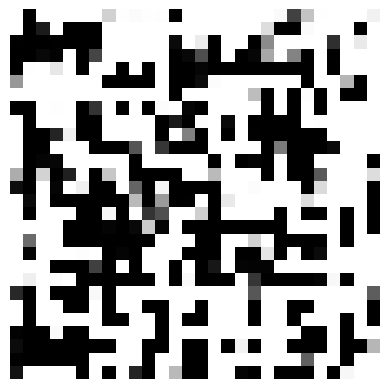

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
2/2 ━━━━━━━

In [13]:
# epochs = 100000
epochs = 100
batch_size = 64

for epoch in range(epochs+1):
   
    noise = np.random.normal(0, 1, (batch_size, 100))
    generated_images = generator_cnn.predict(noise)

    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator_cnn.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator_cnn.train_on_batch(generated_images, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    noise = np.random.normal(0, 1, (batch_size, 100))
    valid_labels = np.ones((batch_size, 1))
    g_loss = gan_cnn.train_on_batch(noise, valid_labels)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {d_loss[0]}, G Loss: {g_loss}")

    if epoch % 1000 == 0:
        test_noise = np.random.normal(0, 1, (1, 100))
        test_img = generator_cnn.predict(test_noise)[0].reshape(28, 28)
        plt.imshow(test_img, cmap='gray')
        plt.axis('off')
        plt.show()

## Conditional Generative Adversarial Network


Conditional Generative Adversarial Networks (CGANs) are a specialized type of Generative Adversarial Network (GAN) that generate data based on specific conditions such as labels or descriptions. Unlike standard GANs that produce random outputs, CGANs control the generation process by adding additional information which allows the creation of targeted and precise data.

For example we have a dataset with various car brands, a CGAN can be conditioned to generate images of only Mercedes cars by specifying "Mercedes" as the condition. This conditioning mechanism helps it to generate data that closely aligns with the desired attributes or categories. In this article, we will see more about CGAN and its core concepts including a practical example using the CIFAR-10 dataset.

## Architecture and Working

Conditional GANs extend the basic GAN framework by conditioning both the generator and discriminator on additional information. This conditioning helps to direct the generation process helps in making it more controlled and focused.

### 1. Generator in CGANs:
The generator in a CGAN takes both random noise and the conditioning information (like class labels) as input to generate data that adheres to the specified conditions. For instance, if we want to generate images of a specific class (e.g., "cat"), the generator will learn to produce images that resemble cats by incorporating the class label into its input. This allows for more targeted and relevant data generation compared to standard GANs.

* Random Noise (z): A vector of random values that adds diversity to generated outputs.
* Conditioning Information (y): Extra data like labels or context that guides what the generator produces for example a class label such as "cat" or "dog".

### 2. Discriminator in CGANs:
The discriminator in a CGAN is also conditioned on the same additional information as the generator. It evaluates both real and generated data based on the provided conditions. For example, if the discriminator is conditioned on class labels, it will assess whether the generated image of a "cat" is realistic and belongs to the "cat" class. This conditioning allows the discriminator to provide more specific feedback to the generator, improving the quality and relevance of the generated data.
* Real Data (x): Actual data samples from the dataset.
* Generated Data (G(z|y)): Data produced by the generator based on random noise and conditioning information.
* Conditioning Information (y): The same extra data used by the generator to guide the generation process.

### 3. Interaction Between Generator and Discriminator:

In a CGAN, the generator and discriminator interact in an adversarial manner. The generator tries to produce data that not only looks realistic but also matches the specified conditions, while the discriminator evaluates the authenticity of the generated data based on those conditions. This dynamic encourages the generator to create more accurate and relevant outputs, as it receives feedback from the discriminator that is specific to the conditions provided.

### 4. Loss Function and Training:

The loss function in a CGAN is designed to optimize both the generator and discriminator while incorporating the conditioning information. The generator aims to minimize the loss by producing data that the discriminator classifies as real and matches the conditions, while the discriminator tries to maximize its ability to distinguish between real and generated data based on those conditions.
* Generator Loss: The generator's loss function encourages it to produce data that the discriminator classifies as real and matches the conditioning information. It can be expressed as:
$$L_G = -\log(D(G(z|y)))$$
Where $G(z|y)$ is the output of the generator given random noise $z$ and conditioning information $y$, and $D(G(z|y))$ is the discriminator's output for the generated data.
* Discriminator Loss: The discriminator's loss function encourages it to correctly classify real data and generated data based on the conditioning information. It can be expressed as:
$$L_D = -\log(D(x|y)) - \log(1 - D(G(z|y)))$$
Where $x$ is a real data sample, $G(z|y)$ is the output of the generator given random noise $z$ and conditioning information $y$, $D(x|y)$ is the discriminator's output for the real data, and $D(G(z|y))$ is the discriminator's output for the generated data.

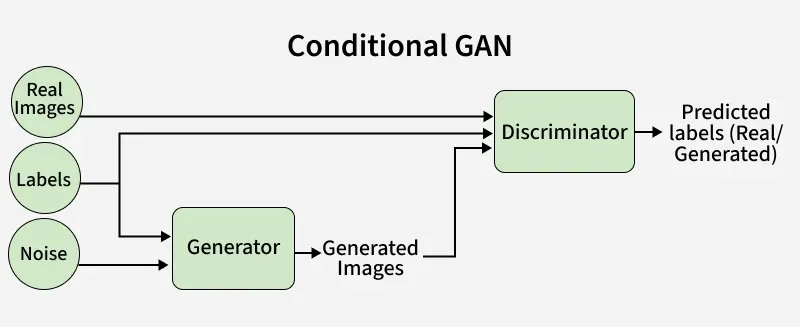



### Implementation

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
from keras.preprocessing import image
import keras.backend as K
import matplotlib.pyplot as plt
import numpy as np
import time
from tqdm import tqdm

batch_size = 16
epoch_count = 50
noise_dim = 100 
n_class = 10
tags = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
img_size = 32

(X_train, y_train), (_, _) = cifar10.load_data()

X_train = (X_train - 127.5) / 127.5

dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset = dataset.shuffle(buffer_size=1000).batch(batch_size)

plt.figure(figsize=(2,2))
idx = np.random.randint(0,len(X_train))
img = image.array_to_img(X_train[idx], scale=True)
plt.imshow(img)
plt.axis('off')
plt.title(tags[y_train[idx][0]])
plt.show()
# Step 4: Defining Loss Functions and Optimizers

bce_loss = tf.keras.losses.BinaryCrossentropy()


def discriminator_loss(real, fake):
    real_loss = bce_loss(tf.ones_like(real), real)
    fake_loss = bce_loss(tf.zeros_like(fake), fake)
    total_loss = real_loss + fake_loss
    return total_loss
  
def generator_loss(preds):
    return bce_loss(tf.ones_like(preds), preds)
  
d_optimizer=Adam(learning_rate=0.0002, beta_1 = 0.5)
g_optimizer=Adam(learning_rate=0.0002, beta_1 = 0.5)

# Step 5: Building the Generator Model

def build_generator():


    in_label = tf.keras.layers.Input(shape=(1,))
    li = tf.keras.layers.Embedding(n_class, 50)(in_label)

    n_nodes = 8 * 8
    li = tf.keras.layers.Dense(n_nodes)(li)
    li = tf.keras.layers.Reshape((8, 8, 1))(li)
    in_lat = tf.keras.layers.Input(shape=(noise_dim,))

    n_nodes = 128 * 8 * 8
    gen = tf.keras.layers.Dense(n_nodes)(in_lat)
    gen = tf.keras.layers.LeakyReLU(alpha=0.2)(gen)
    gen = tf.keras.layers.Reshape((8, 8, 128))(gen)
    merge = tf.keras.layers.Concatenate()([gen, li])

    gen = tf.keras.layers.Conv2DTranspose(
        128, (4, 4), strides=(2, 2), padding='same')(merge)  
    gen = tf.keras.layers.LeakyReLU(alpha=0.2)(gen)

    gen = tf.keras.layers.Conv2DTranspose(
        128, (4, 4), strides=(2, 2), padding='same')(gen)  
    gen = tf.keras.layers.LeakyReLU(alpha=0.2)(gen)

    out_layer = tf.keras.layers.Conv2D(
        3, (8, 8), activation='tanh', padding='same')(gen)  

    model = Model([in_lat, in_label], out_layer)
    return model


g_model = build_generator()
g_model.summary()

# Step 6: Building the Discriminator Model
def build_discriminator():
    
 
  in_label = tf.keras.layers.Input(shape=(1,))
  
  li = tf.keras.layers.Embedding(n_class, 50)(in_label)
  
  n_nodes = img_size * img_size 
  li = tf.keras.layers.Dense(n_nodes)(li) 
 
  li = tf.keras.layers.Reshape((img_size, img_size, 1))(li) 


  
  in_image = tf.keras.layers.Input(shape=(img_size, img_size, 3)) 
  
  merge = tf.keras.layers.Concatenate()([in_image, li]) 

  fe = tf.keras.layers.Conv2D(128, (3,3), strides=(2,2), padding='same')(merge) 
  fe = tf.keras.layers.LeakyReLU(alpha=0.2)(fe)
  
  fe = tf.keras.layers.Conv2D(128, (3,3), strides=(2,2), padding='same')(fe) 
  fe = tf.keras.layers.LeakyReLU(alpha=0.2)(fe)
  
  fe = tf.keras.layers.Flatten()(fe) 
  
  fe = tf.keras.layers.Dropout(0.4)(fe)
  
  out_layer = tf.keras.layers.Dense(1, activation='sigmoid')(fe)

  model = Model([in_image, in_label], out_layer)
      
  return model


d_model = build_discriminator()
d_model.summary()

## Step 7: Creating Training Step Function

@tf.function
def train_step(dataset):
   
    real_images, real_labels = dataset
 
    random_latent_vectors = tf.random.normal(shape=(batch_size, noise_dim))
    generated_images = g_model([random_latent_vectors, real_labels])

    with tf.GradientTape() as tape:
        pred_fake = d_model([generated_images, real_labels])
        pred_real = d_model([real_images, real_labels])
        
        d_loss = discriminator_loss(pred_real, pred_fake)
      
    grads = tape.gradient(d_loss, d_model.trainable_variables)
   
    d_optimizer.apply_gradients(zip(grads, d_model.trainable_variables))

   
    random_latent_vectors = tf.random.normal(shape=(batch_size, noise_dim))
   

    with tf.GradientTape() as tape:
        fake_images = g_model([random_latent_vectors, real_labels])
        predictions = d_model([fake_images, real_labels])
        g_loss = generator_loss(predictions)
    
    grads = tape.gradient(g_loss, g_model.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, g_model.trainable_variables))
    
    return d_loss, g_loss

## Step 8: Visualizing Generated Images

def show_samples(num_samples, n_class, g_model):
    fig, axes = plt.subplots(10,num_samples, figsize=(10,20)) 
    fig.tight_layout()
    fig.subplots_adjust(wspace=None, hspace=0.2)

    for l in np.arange(10):
      random_noise = tf.random.normal(shape=(num_samples, noise_dim))
      label = tf.ones(num_samples)*l
      gen_imgs = g_model.predict([random_noise, label])
      for j in range(gen_imgs.shape[0]):
        img = image.array_to_img(gen_imgs[j], scale=True)
        axes[l,j].imshow(img)
        axes[l,j].yaxis.set_ticks([])
        axes[l,j].xaxis.set_ticks([])

        if j ==0:
          axes[l,j].set_ylabel(tags[l])
    plt.show()

    # Train model 
    def train(dataset, epochs=epoch_count):

 def train(dataset, epochs=epoch_count):

    for epoch in range(epochs):
        print('Epoch: ', epochs)
        d_loss_list = []
        g_loss_list = []
        q_loss_list = []
        start = time.time()
        
        itern = 0
        for image_batch in tqdm(dataset):
            d_loss, g_loss = train_step(image_batch)
            d_loss_list.append(d_loss)
            g_loss_list.append(g_loss)
            itern=itern+1
                
        show_samples(3, n_class, g_model)
            
        print (f'Epoch: {epoch} -- Generator Loss: {np.mean(g_loss_list)}, Discriminator Loss: {np.mean(d_loss_list)}\n')
        print (f'Took {time.time()-start} seconds. \n\n')
        
 
train(dataset, epochs=epoch_count)

## Cycle Generative Adversarial Network (CycleGAN)

CycleGAN is a type of Generative Adversarial Network (GAN) designed for unpaired image-to-image translation tasks. It enables the transformation of images from one domain to another without requiring paired training data. For example, CycleGAN can be used to convert photos of horses into photos of zebras and vice versa, even if there are no direct pairs of horse and zebra images in the training dataset.

Generative Adversarial Networks (GANs) use two neural networks i.e a generator that creates images and a discriminator that decides if those images look real or fake. Traditional GANs need paired data means each input image must have a matching output image. But finding such paired images is difficult which limits their practical use.

CycleGAN solves this problem by learning to change images from one style to another without needing matching pairs. It understands the features of the new style and transforms the original images accordingly. This makes it useful for tasks like changing seasons in photos, turning one animal into another or converting pictures into paintings. In this article we will see more about CycleGAN and its core concepts.

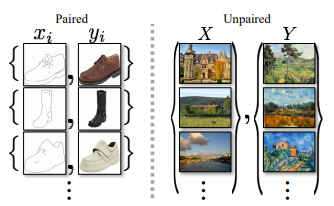

* The process starts with an input image(x) and Generator G translates it to the target domain like turning a photo into a painting. Then generator F takes this transformed image and maps it back to the original domain helps in reconstructing an image close to the input.
* The model measures the difference between the original and reconstructed images using a loss function like mean squared error. This cycle consistency loss helps the network to learn meaningful, reversible mappings between the two domains.

## Architecture of CycleGAN

**1. Generators:** Create new images in the target style.

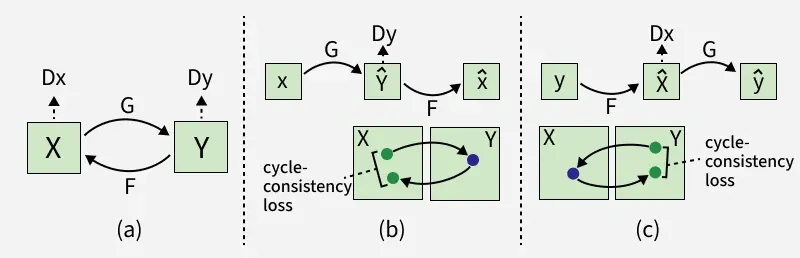

**2. Discriminators:** Evaluate the authenticity of generated images.

**3. Cycle Consistency Loss:** Ensures that the transformation is reversible and meaningful by comparing the original image with the reconstructed image after a cycle of transformations.

* 1. Forward Cycle Consistency Loss: $$L_{cyc}(G, F) = \mathbb{E}_{x \sim p_{data}(x)}[||F(G(x)) - x||_1]$$

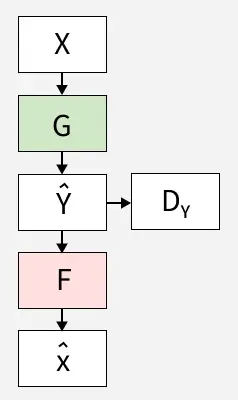

* 2. Backward Cycle Consistency Loss: $$L_{cyc}(F, G) = \mathbb{E}_{y \sim p_{data}(y)}[||G(F(y)) - y||_1]$$

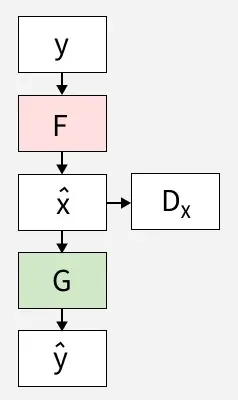

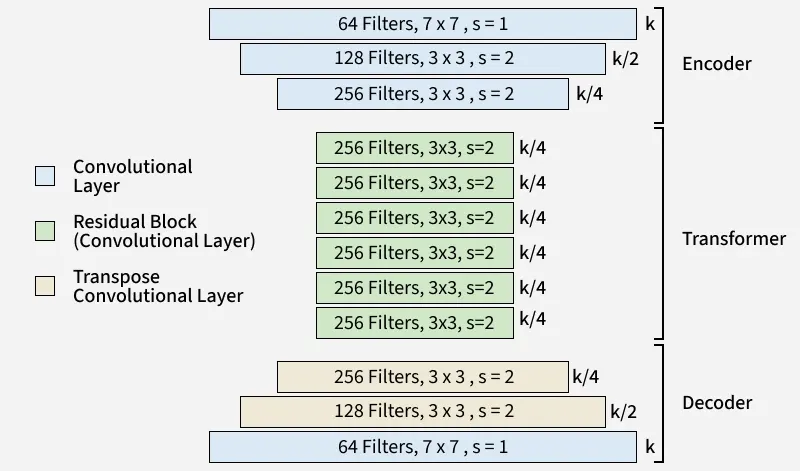

## Discriminator Architecture (PatchGAN)

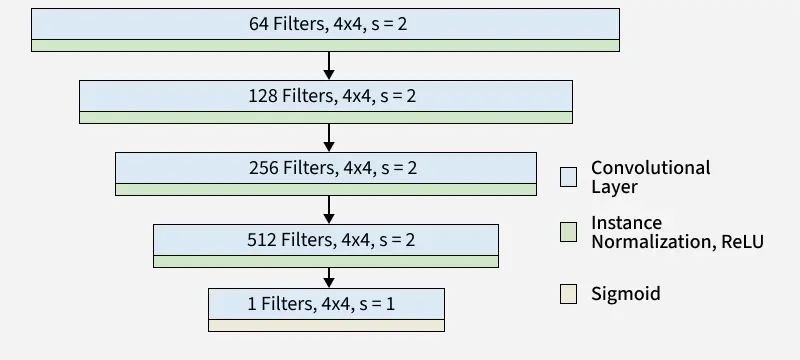



## StyleGAN - Style Generative Adversarial Networks


StyleGAN is a generative model that produces highly realistic images by controlling image features at multiple levels from overall structure to fine details like texture and lighting. It is developed by NVIDIA and builds on traditional GANs with a unique architecture that separates style from content which gives precise control over the generated image’s appearance. This makes it useful for creating detailed lifelike images such as human faces that don’t exist in reality. In this article, we’ll see how StyleGAN’s design helps this level of control and realism.

## Architecture of StyleGAN

StyleGAN uses the standard GAN framework by modifying the generator while the discriminator remains similar to traditional GANs. These changes helps to fine control over image features and improve image quality. Lets see various architectural components:

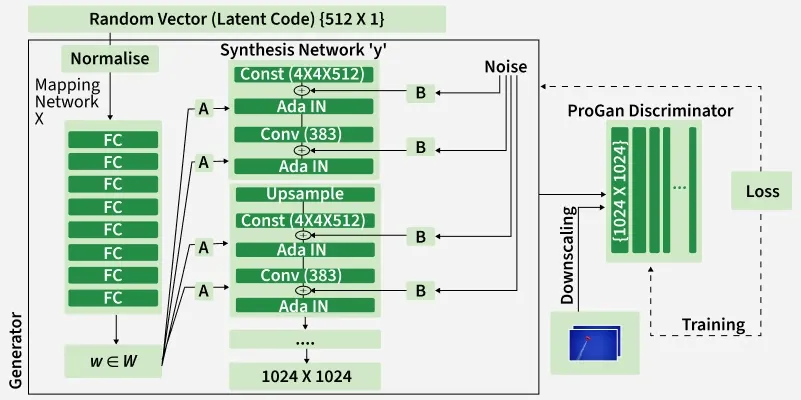

* **1. Progressive Growing of Images** 

StyleGAN starts with generating low-resolution images and progressively increases the resolution during training. This allows the model to learn coarse features first and then refine details as the resolution increases, leading to better image quality and stability during training.

** Bi-linear Sampling:** StyleGAN uses bi-linear sampling to combine features from different layers of the generator. This allows it to control both global structure and fine details in the generated images, enabling the creation of highly realistic and diverse outputs.

**3. Mapping Network and Style Network**

StyleGAN introduces a mapping network that transforms the input latent vector into an intermediate latent space. This intermediate space allows for better disentanglement of features, making it easier to control specific attributes of the generated images. The style network then uses this intermediate representation to modulate the generator’s layers, giving precise control over the image’s style and appearance.

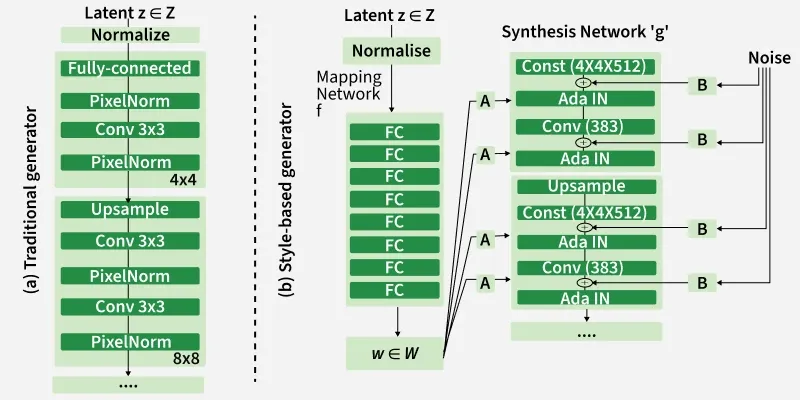

### 4. Constant Input and Noise Injection

* This focuses the model on applying style changes rather than learning basic structure from noise.
* To add natural-looking random variations like skin pores, wrinkles or freckles, Gaussian noise is added independently to each convolutional layer during synthesis.
* This noise introduces stochastic detail without affecting overall structure helps in improving realism.

### 5. Mixing Regularization

* To encourage the generator to learn more robust and diverse representations, StyleGAN uses mixing regularization during training. This involves randomly mixing two different latent vectors at various layers of the generator, which helps to prevent overfitting and promotes the learning of more general features. By doing this, the model can generate a wider variety of images and improve its ability to create realistic outputs.

### 6. Style Control at Different Resolutions

* StyleGAN allows for control over image features at different resolutions. By modulating the generator’s layers with style information, it can influence both high-level attributes (like pose and shape) and low-level details (like texture and color). This multi-resolution control enables the creation of images that are not only realistic but also highly customizable based on the desired attributes.

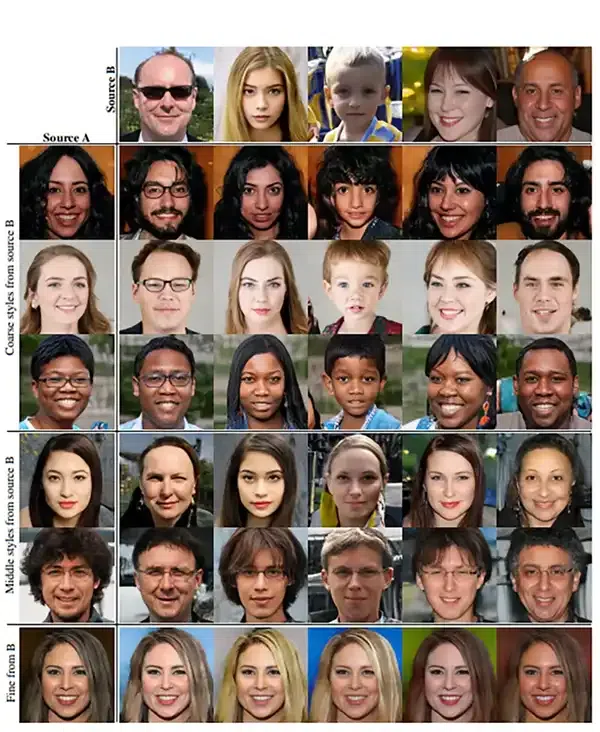

### 7. Feature Disentanglement Studies

* StyleGAN’s architecture promotes feature disentanglement, meaning that different aspects of the generated images can be controlled independently. For example, one can adjust the latent vector to change the hairstyle of a generated face without affecting other features like facial expression or background. This disentanglement allows for more precise and intuitive control over the generated content, making it easier to create specific variations of images while maintaining overall realism.

* Perceptual Path Length: Measures how smooth the transition between two generated images is when interpolating between their latent vectors. Shorter path length shows smoother changes.
* Linear Separability: Tests whether certain features like gender, age, etc and can be separated using a simple linear classifier in the latent space which shows how well features are disentangled .

These studies show that the intermediate latent space wis more disentangled and easier to separate than the original latent space z showing the effectiveness of the mapping network.

**Results:**

* StyleGAN achieves state-of-the-art image quality on the CelebA-HQ dataset which is a high-resolution face dataset used for benchmarking.
* NVIDIA also introduced the Flickr-Faces-HQ (FFHQ) dataset which offers more diversity in age, ethnicity and backgrounds. It produces highly realistic images on FFHQ as well.